## Load data and libraries

In [ ]:
# import utilities from the correct relative path
from experiments.silver_seq import silver_seq_utils as utils
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#other needed packages
import seaborn as sns
import matplotlib.pyplot as plt
import umap
import pandas as pd
import numpy as np
import os
import sys
print(f'environment: {sys.executable}')

In [3]:
#load da data
X, _, silver_seq_meta = utils.load_silver_seq_data()

#annotate if sample is last (at death)
silver_seq_meta['is_last_sample'] = silver_seq_meta.groupby('donor_id_alias')['year_sample'].transform('max') == silver_seq_meta['year_sample']

#apoe4
def apoe_num(val):
  val=str(val)
  if val=='44':
    return 2
  if '4' in val:
    return 1
  return 0

silver_seq_meta['apoe2'] = [apoe_num(v) for v in silver_seq_meta['apoe']]

In [4]:
silver_seq_meta.head()

,donor_id,donor_id_alias,sample_id_alias,year_sample,donor_status_score,donor_group,braak_stage,apoe,apoe_carrier,apoe_dose,age_at_death,sex,max_year,age_at_collection,is_last_sample,apoe2
0,8140,AD_1,AD_1_02_1,2002,A,AD,5,34,apoe4,apoe4,85,F,2013,74,False,1
1,8140,AD_1,AD_1_04_1,2004,A,AD,5,34,apoe4,apoe4,85,F,2013,76,False,1
2,8140,AD_1,AD_1_08_1,2008,A,AD,5,34,apoe4,apoe4,85,F,2013,80,False,1
3,8140,AD_1,AD_1_09_1,2009,A,AD,5,34,apoe4,apoe4,85,F,2013,81,False,1
4,8140,AD_1,AD_1_11_1,2011,A,AD,5,34,apoe4,apoe4,85,F,2013,83,False,1


/tmp/ipykernel_4711/762606913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


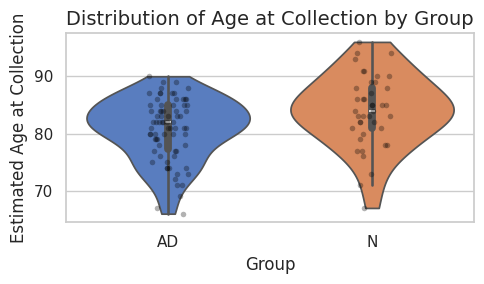

In [5]:
# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(5, 3))

# Create the violin plot
# We plot 'group' on the x-axis to compare the age distributions
sns.violinplot(
    data=silver_seq_meta,
    x='donor_group',
    y='age_at_collection',
    inner="box",           # Show a miniature boxplot inside the violin
    palette="muted",       # Aesthetic color palette
    cut=0                  # Limit the violin to the actual data range
)

# Overlay individual points (jittered) to see the actual sample size (N=115)
sns.stripplot(
    data=silver_seq_meta,
    x='donor_group',
    y='age_at_collection',
    color="black",
    alpha=0.3,
    size=4,
    jitter=True
)

plt.title('Distribution of Age at Collection by Group', fontsize=14)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Estimated Age at Collection', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4711/1738357211.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=silver_seq_meta, x='sex', palette='pastel', ax=ax[0])


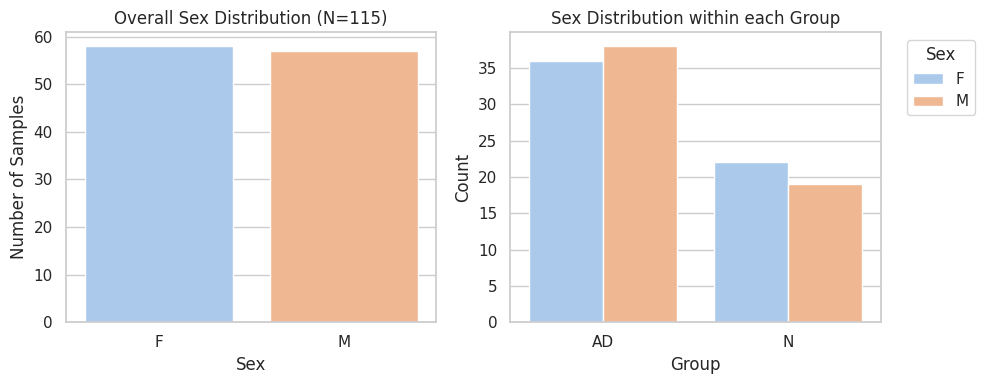

In [6]:
# Create a figure with two subplots arranged side-by-side
fig, ax = plt.subplots(1, 2, figsize=(10, 4)) # 1 row, 2 columns

# 1. Simple Bar Plot (Counts) for Sex
sns.countplot(data=silver_seq_meta, x='sex', palette='pastel', ax=ax[0])
ax[0].set_title('Overall Sex Distribution (N=115)')
ax[0].set_xlabel('Sex')
ax[0].set_ylabel('Number of Samples')

# 2. Grouped Bar Plot (Sex by Group)
sns.countplot(data=silver_seq_meta, x='donor_group', hue='sex', palette='pastel', ax=ax[1])
ax[1].set_title('Sex Distribution within each Group')
ax[1].set_xlabel('Group')
ax[1].set_ylabel('Count')
ax[1].legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

### Data Exploration - UMAPs

In [ ]:
def plot_gene_umap(X, metadata, color_by, top_perc=100):
    """
    Generates a UMAP plot using the most variable genes.

    Args:
        X (pd.DataFrame): Expression data (Rows: samples, Cols: genes).
        metadata (pd.DataFrame): Metadata containing 'sample_id_alias'.
        color_by (str): Metadata column for point coloring.
        top_perc (float): Top percentage (0-100) of most variable genes to keep.
    """

    # 1. Filter by Variance
    if top_perc < 100:
        # Calculate variance for each gene (column)
        gene_variances = X.var(axis=0).sort_values(ascending=False)

        # Determine number of genes to keep
        n_genes = int(len(gene_variances) * (top_perc / 100))
        # Handle edge case where top_perc might result in 0 genes
        n_genes = max(1, n_genes)

        top_genes = gene_variances.head(n_genes).index
        X_filtered = X[top_genes]
        print(f"🧬 Using the top {top_perc}% most variable genes ({len(top_genes)} genes).")
    else:
        X_filtered = X
        print(f"🧬 Using all {X.shape[1]} genes.")

    # 2. Align Metadata with X
    # Ensure metadata order matches X's row index
    meta_aligned = metadata.set_index('sample_id_alias').reindex(X_filtered.index)

    if meta_aligned[color_by].isnull().any():
        print(f"⚠️ Warning: Missing metadata in '{color_by}' for some samples.")

    # 3. Dimensionality Reduction
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_filtered)

    # 4. Plotting
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=meta_aligned[color_by],
        palette='magma' if meta_aligned[color_by].dtype in ['float64', 'int64'] else 'viridis',
        alpha=0.8,
        s=60
    )

    plt.title(f'UMAP: Top {top_perc}% Variable Genes (n={X_filtered.shape[1]})\nColored by: {color_by}')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=color_by)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
silver_seq_meta.columns

Index(['donor_id', 'donor_id_alias', 'sample_id_alias', 'year_sample',
       'donor_status_score', 'donor_group', 'braak_stage', 'apoe',
       'apoe_carrier', 'apoe_dose', 'age_at_death', 'sex', 'max_year',
       'age_at_collection'],
      dtype='object')

In [ ]:
plot_gene_umap(X, silver_seq_meta, 'donor_group', 10)

🧬 Using the top 10% most variable genes (11 genes).
⚠️ Warning: Missing metadata in 'donor_group' for some samples.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
plot_gene_umap(X, silver_seq_meta, 'age_at_collection', 0.66)

🧬 Using the top 0.66% most variable genes (1 genes).
⚠️ Warning: Missing metadata in 'age_at_collection' for some samples.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
plot_gene_umap(X, silver_seq_meta, 'age_at_death', 10)

🧬 Using the top 10% most variable genes (11 genes).
⚠️ Warning: Missing metadata in 'age_at_death' for some samples.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


## Clustering test

In [ ]:
from sklearn.cluster import KMeans

def perform_clustering(X, n_clusters=2):
    """
    Performs K-means clustering and returns a dataframe mapping sample IDs to clusters.
    """
    # 1. Initialize and fit KMeans
    # We use random_state for reproducibility
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    # It is often better to cluster on the data used for the UMAP
    # (after variance filtering and scaling)
    cluster_labels = kmeans.fit_predict(X)

    # 2. Create a results DataFrame
    cluster_df = pd.DataFrame({
        'sample_id_alias': X.index,
        'cluster_assignment': cluster_labels
    })

    # Convert cluster IDs to strings/factors for easier plotting
    cluster_df['cluster_assignment'] = cluster_df['cluster_assignment'].astype(str)

    return cluster_df

#CLUSTER
cluster_results = perform_clustering(X, n_clusters=3)

# Merge back into main metadata for easy downstream use
silver_seq_meta_updated = silver_seq_meta.merge(cluster_results, on='sample_id_alias')

print("Cluster Assignments:")
print(silver_seq_meta_updated[['sample_id_alias', 'cluster_assignment']].head())

Cluster Assignments:
  sample_id_alias cluster_assignment
0       AD_1_02_1                  0
1       AD_1_04_1                  0
2       AD_1_08_1                  0
3       AD_1_09_1                  0
4       AD_1_11_1                  0


🧬 Using all 60675 genes.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


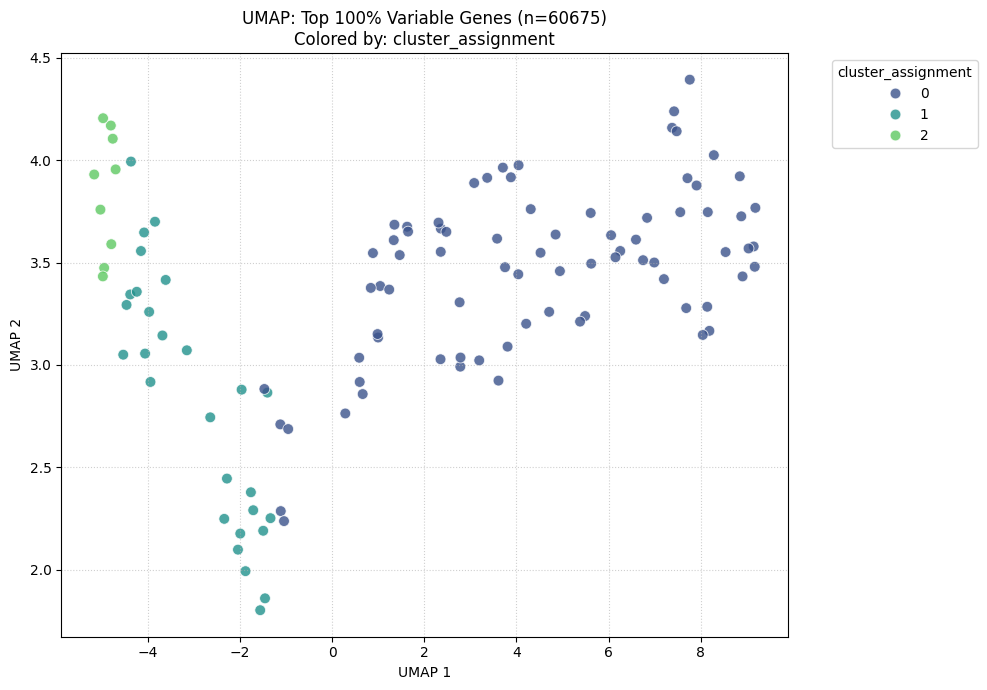

In [ ]:
# Assuming X is your gene expression matrix
plot_gene_umap(X, silver_seq_meta_updated, color_by='cluster_assignment', top_perc=100)

In [ ]:
silver_seq_meta.head()

,donor_id,donor_id_alias,sample_id_alias,year_sample,donor_status_score,donor_group,braak_stage,apoe,apoe_carrier,apoe_dose,age_at_death,sex,max_year,age_at_collection
0,8140,AD_1,AD_1_02_1,2002,A,AD,5,34,apoe4,apoe4,85,F,2013,74
1,8140,AD_1,AD_1_04_1,2004,A,AD,5,34,apoe4,apoe4,85,F,2013,76
2,8140,AD_1,AD_1_08_1,2008,A,AD,5,34,apoe4,apoe4,85,F,2013,80
3,8140,AD_1,AD_1_09_1,2009,A,AD,5,34,apoe4,apoe4,85,F,2013,81
4,8140,AD_1,AD_1_11_1,2011,A,AD,5,34,apoe4,apoe4,85,F,2013,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,647,N_9,N_9_00_1,2000,N--,N,2,23,no_apoe4,no_apoe4,94,F,2012,82
111,647,N_9,N_9_03_1,2003,N-,N,2,23,no_apoe4,no_apoe4,94,F,2012,85
112,647,N_9,N_9_06_1,2006,N,N,2,23,no_apoe4,no_apoe4,94,F,2012,88
113,647,N_9,N_9_08_1,2008,N,N,2,23,no_apoe4,no_apoe4,94,F,2012,90


## Baseline Models: How much predictive power do we have with the metdata information alone?

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Prepare your features (dropping non-predictive IDs)
# We use pd.get_dummies to convert 'sex' and 'apoe' into numeric columns
features = ['sex', 'age_at_collection', 'apoe2']
X_meta = pd.get_dummies(silver_seq_meta[features], drop_first=True)
y_meta = silver_seq_meta['donor_group']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_meta, y_meta, test_size=0.2, random_state=42, stratify=y_meta
)

# 3. Initialize and Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Evaluate
predictions = rf.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

          AD       0.87      0.87      0.87        15
           N       0.75      0.75      0.75         8

    accuracy                           0.83        23
   macro avg       0.81      0.81      0.81        23
weighted avg       0.83      0.83      0.83        23



<Figure size 800x600 with 0 Axes>

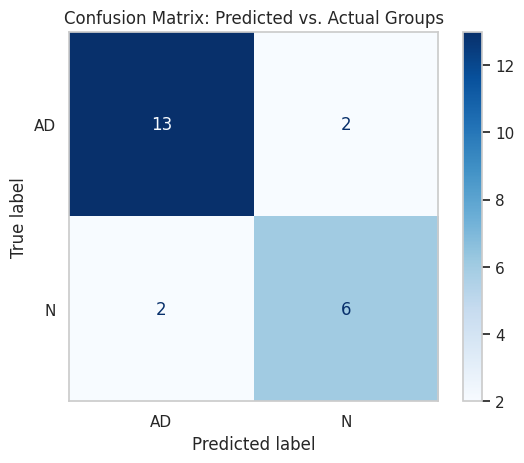

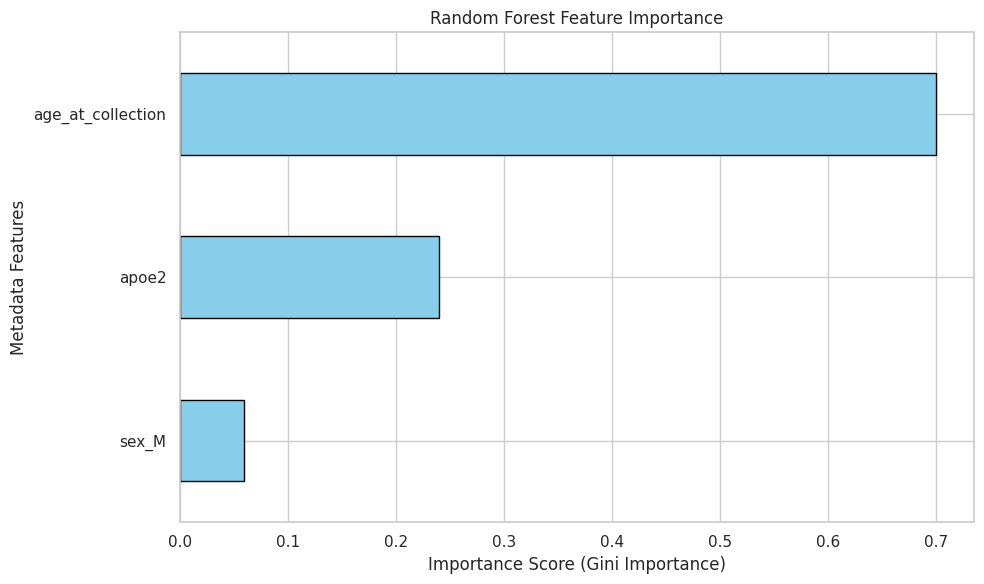

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd

# --- Plot 1: Confusion Matrix ---
# This uses the test set to see how well the model generalizes
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap='Blues',
    values_format='d'
)
plt.title('Confusion Matrix: Predicted vs. Actual Groups')
plt.grid(False) # Clean up the grid for better visibility
plt.show()

# --- Plot 2: Feature Importance ---
# We extract the importance scores and map them to column names
importances = rf.feature_importances_
feature_names = X_meta.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
forest_importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Metadata Features')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

# Using 5 folds means each test set has 23 samples
scores = cross_val_score(rf, X_meta, y_meta, cv=5)

print(f"Mean Accuracy: {scores.mean():.2f}")
print(f"Accuracy Standard Deviation: {scores.std():.2f}")

Mean Accuracy: 0.66
Accuracy Standard Deviation: 0.07


In [10]:
#AUC
from sklearn.metrics import roc_auc_score

# Get probabilities for each class
# This returns an array of shape [n_samples, n_classes]
y_probs = rf.predict_proba(X_test)
auc_score = roc_auc_score(y_test, y_probs[:, 1])
print(f"🏆 Binary ROC-AUC Score: {auc_score:.3f}")


🏆 Binary ROC-AUC Score: 0.838


## Add just PHGDH gene to classifiers

In [ ]:
utils.translate_symbols(['PHGDH'])

,query
2781,ENSG00000092621


In [11]:
interest_gene = X.loc['ENSG00000092621']

In [12]:
silver_seq_meta['PHGDH'] = silver_seq_meta['sample_id_alias'].map(interest_gene)

              precision    recall  f1-score   support

          AD       0.78      0.93      0.85        15
           N       0.80      0.50      0.62         8

    accuracy                           0.78        23
   macro avg       0.79      0.72      0.73        23
weighted avg       0.79      0.78      0.77        23



<Figure size 400x300 with 0 Axes>

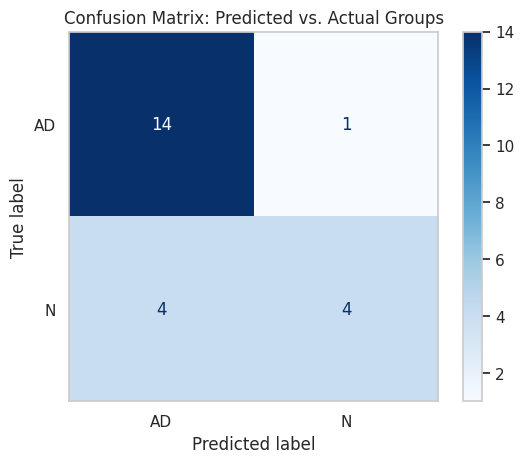

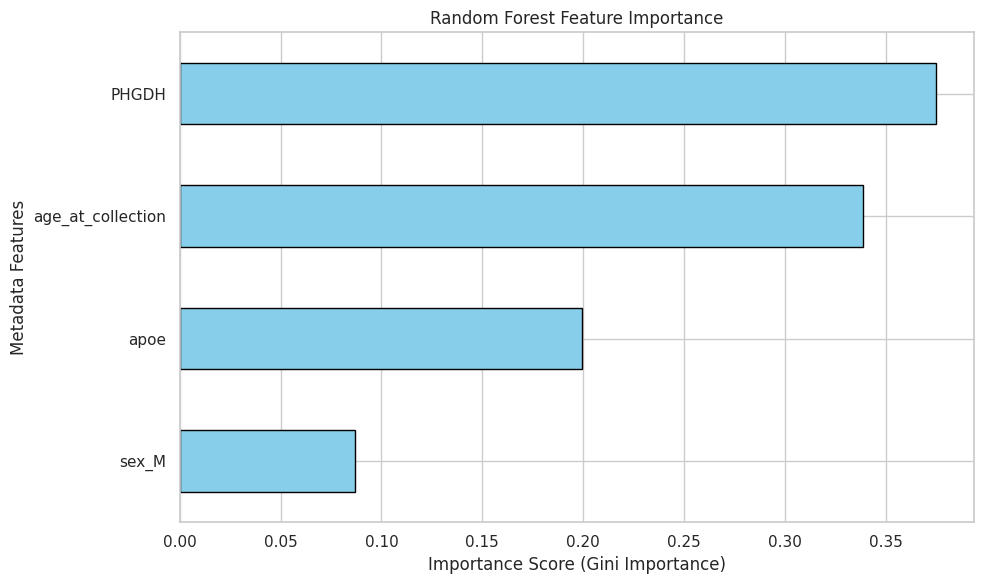

In [14]:
features = ['age_at_collection', 'sex', 'apoe', 'PHGDH']
X_meta = pd.get_dummies(silver_seq_meta[features], drop_first=True)
y_meta = silver_seq_meta['donor_group']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_meta, y_meta, test_size=0.2, random_state=42, stratify=y_meta
)

# 3. Initialize and Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Evaluate
predictions = rf.predict(X_test)
print(classification_report(y_test, predictions))

plt.figure(figsize=(4, 3))
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap='Blues',
    values_format='d'
)
plt.title('Confusion Matrix: Predicted vs. Actual Groups')
plt.grid(False) # Clean up the grid for better visibility
plt.show()

# --- Plot 2: Feature Importance ---
# We extract the importance scores and map them to column names
importances = rf.feature_importances_
feature_names = X_meta.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
forest_importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('Metadata Features')
plt.tight_layout()
plt.show()

In [15]:
y_probs = rf.predict_proba(X_test)
auc_score = roc_auc_score(y_test, y_probs[:, 1])
print(f"🏆 Binary ROC-AUC Score: {auc_score:.3f}")

🏆 Binary ROC-AUC Score: 0.758
